Notebook to resample the Thiele+23 fiducial dataset to use the analytic Galactic distribution of Breivik+20. Sampling methods adapted from the (now defunct) [MC_samp.py](https://github.com/COSMIC-PopSynth/COSMIC/blob/746eeba950a02c45da312e02b3af6ad3c5c34876/cosmic/MC_samp.py) in the 2020 COSMIC release. We note that there was an error in the original code, resulting in over-sampling near r=0 due to unaccounted-for change-of-variable effects; we resolve this by sampling in 3D cartesian space.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp

Load the Thiele fiducial dataset:

In [6]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'

In [9]:
# all keys are "data regardless of your filename"
# the 'fiducial' model should either be LISA_band_FZ_fiducial_Z or LISA_band_FZ_alpha25_Z
binaries = pd.read_csv(file)

In [10]:
binaries

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_gal[kpc],y_gal[kpc],z_gal[kpc],Pala_reassigned
0,0.699904,0.131682,0.000300,1.601622,-7.656474,0.523081,0.610373,0.0
1,0.700249,0.122204,0.000316,1.142549,-7.923867,0.656950,0.328620,0.0
2,0.699948,0.111794,0.000329,1.517297,-8.808587,-0.138341,0.548997,0.0
3,0.697876,0.103482,0.000343,1.630793,-8.809043,0.143913,0.389516,0.0
4,0.700038,0.112346,0.000329,2.506788,-7.920000,-0.110300,-0.079635,0.0
...,...,...,...,...,...,...,...,...
7279,0.701070,0.163327,0.000266,2.131852,-8.474465,0.078649,0.134412,0.0
7280,0.702206,0.039757,0.000422,1.321062,-8.817304,0.555422,-0.303299,0.0
7281,0.700873,0.200035,0.000176,2.137771,-8.956073,0.118308,0.039737,0.0
7282,0.699103,0.161022,0.000269,0.659383,-7.837356,-0.558326,0.437242,0.0


Now make a BLIP-friendly version:

In [12]:
blip_columns = ['f','h','lat','long']

In [15]:
binaries.columns

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]', ' Pala_reassigned'],
      dtype='object')

In [16]:
xG, yG, zG = binaries[' x_gal[kpc]'].to_numpy(), binaries[' y_gal[kpc]'].to_numpy(), binaries[' z_gal[kpc]'].to_numpy()

In [17]:
## convert to distances and lat/long ecliptic coords
gc = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
SSBc = gc.transform_to(cc.BarycentricMeanEcliptic)

In [18]:
SSBc

<SkyCoord (BarycentricMeanEcliptic: equinox=J2000.000): (lon, lat, distance) in (deg, deg, kpc)
    [(241.70640977,  49.87987727, 0.91536802),
     (279.75223226,  68.70949786, 0.75205248),
     (124.89060731,  13.76951753, 0.87725057), ...,
     ( 83.72907429,  13.08972772, 0.84266117),
     (198.60659988, -23.61332262, 0.75243519),
     (357.40371875,  38.54816442, 0.82796574)]>

In [19]:
## get latitude, longitude
lat = SSBc.lat.to(u.rad).value
long = SSBc.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

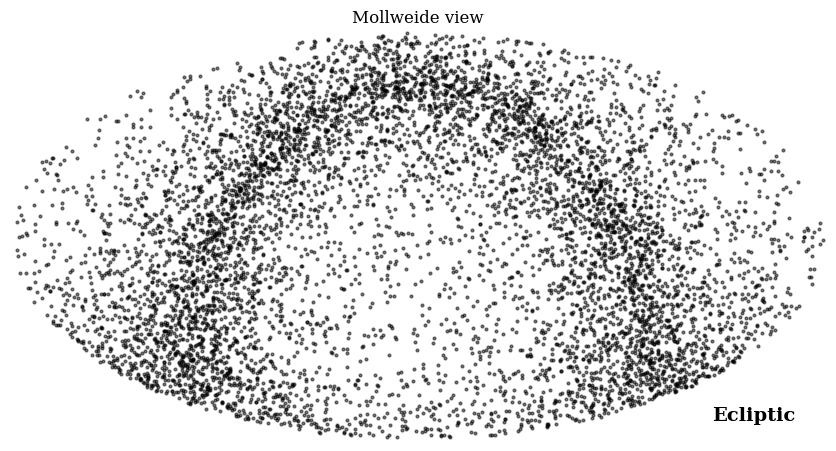

In [22]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

It's a galaxy! Yay.

In [25]:
## making sure we've handled our coordinate transforms correctly
dist = SSBc.distance.to(u.kpc)

Get the quantities needed by BLIP:

In [26]:
binaries.columns

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_gal[kpc]', ' y_gal[kpc]', ' z_gal[kpc]', ' Pala_reassigned'],
      dtype='object')

In [28]:
mc = lw.utils.chirp_mass(binaries['# m1[Msun]'],binaries[' m2[Msun]']).to_numpy()*u.Msun

In [29]:
mc

<Quantity [0.24817485, 0.23789231, 0.22605136, ..., 0.31413102, 0.27793482,
           0.223066  ] solMass>

In [31]:
fs = binaries[' f_gw[Hz]'].to_numpy()

In [32]:
f_orb = fs*u.Hz/2

In [33]:
f_orb

<Quantity [1.4985540e-04, 1.5792325e-04, 1.6444085e-04, ..., 8.8110150e-05,
           1.3451790e-04, 1.6733670e-04] Hz>

In [34]:
## assuming circular binaries
ecc = np.zeros(len(f_orb))

In [35]:
hs = lw.strain.h_0_n(mc,f_orb,ecc,2,dist)

In [36]:
blip_df = pd.DataFrame(data=np.vstack((fs,hs.flatten(),lat,long)).T,columns=blip_columns)

In [37]:
blip_df.head()

,f,h,lat,long
0,0.000300,5.097921e-23,0.870568,4.218573
1,0.000316,5.988171e-23,1.199207,4.882598
2,0.000329,4.843645e-23,0.240323,2.179752
3,0.000343,5.112263e-23,0.489618,1.874893
4,0.000329,1.701366e-22,-0.713286,4.823727


In [38]:
datapath = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/'

In [ ]:
blip_df.to_csv(datapath+'dat_mD1000_final_blip.txt',index=False,sep=' ',header=False)

# DONEZO